# Taller Unidad 4 — EDA: Dragon Ball API
**Curso:** Bases de Datos para Ciencia de Datos  
**Docente:** Miguel Ramos García  

Este notebook se conecta a MongoDB, lee los datos RAW de personajes de Dragon Ball y realiza un Análisis Exploratorio de Datos (EDA) completo.

## 0. Imports y conexión a MongoDB

In [1]:
import pymongo
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

# Conexión
client     = pymongo.MongoClient('mongodb://localhost:27017/')
db         = client['taller4_db']
collection = db['raw_data']

print(f'Total de documentos en raw_data: {collection.count_documents({})}')
print(f'Solo personajes: {collection.count_documents({"_tipo": "character"})}')

Total de documentos en raw_data: 121
Solo personajes: 58


## 1. Selección de Variables

Se filtran únicamente los documentos de tipo **character** y se seleccionan **6 variables** relevantes:

| Variable | Descripción |
|---|---|
| `name` | Nombre del personaje |
| `race` | Raza (Saiyan, Human, Android, etc.) |
| `gender` | Género |
| `affiliation` | Afiliación (Z Fighter, Army of Frieza, etc.) |
| `ki` | Poder Ki base |
| `maxKi` | Poder Ki máximo |

In [2]:
# Leer solo personajes desde MongoDB
projection = {'_id': 0, 'name': 1, 'race': 1, 'gender': 1,
              'affiliation': 1, 'ki': 1, 'maxKi': 1}

cursor = collection.find({'_tipo': 'character'}, projection)
df     = pd.DataFrame(list(cursor))

print(f'Shape del DataFrame: {df.shape}')
df.head(10)

Shape del DataFrame: (58, 6)


,name,ki,maxKi,race,gender,affiliation
0,Goku,60.000.000,90 Septillion,Saiyan,Male,Z Fighter
1,Vegeta,54.000.000,19.84 Septillion,Saiyan,Male,Z Fighter
2,Piccolo,2.000.000,500.000.000,Namekian,Male,Z Fighter
3,Bulma,0,0,Human,Female,Z Fighter
4,Freezer,530.000,52.71 Septillion,Frieza Race,Male,Army of Frieza
5,Zarbon,20.000,30.000,Frieza Race,Male,Army of Frieza
6,Dodoria,18.000,20.000,Frieza Race,Male,Army of Frieza
7,Ginyu,9.000,25.000,Frieza Race,Male,Army of Frieza
8,Celula,250.000.000,5 Billion,Android,Male,Freelancer
9,Gohan,45.000.000,40 septillion,Saiyan,Male,Z Fighter


## 2A. Inspección Básica

In [3]:
# Tipos de datos e información general
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   name         58 non-null     str  
 1   ki           58 non-null     str  
 2   maxKi        58 non-null     str  
 3   race         58 non-null     str  
 4   gender       58 non-null     str  
 5   affiliation  58 non-null     str  
dtypes: str(6)
memory usage: 2.8 KB


In [4]:
# Verificar valores nulos
print('Valores nulos por columna:')
print(df.isnull().sum())

Valores nulos por columna:
name           0
ki             0
maxKi          0
race           0
gender         0
affiliation    0
dtype: int64


In [5]:
# Limpieza: convertir ki y maxKi a numérico
# La API devuelve valores como "90 Septillion", "5 Billion", "500.000.000", etc.
def parse_ki(val):
    """Convierte strings de ki a float interpretando sufijos como Septillion, Billion, etc."""
    if pd.isna(val) or val is None:
        return None
    val_str = str(val).strip()

    multipliers = {
        'septillion': 1e24,
        'sextillion': 1e21,
        'quintillion': 1e18,
        'quadrillion': 1e15,
        'trillion': 1e12,
        'billion': 1e9,
        'million': 1e6,
        'thousand': 1e3,
    }

    val_lower = val_str.lower()
    for word, mult in multipliers.items():
        if word in val_lower:
            before = val_lower.split(word)[0].strip()
            parts = before.replace(",", "").split(".")
            if len(parts) > 2:
                num_str = "".join(parts)
            else:
                num_str = before.replace(",", "")
            try:
                return float(num_str) * mult
            except:
                return None

    # Sin sufijo: puntos son separadores de miles
    clean = val_str.replace(",", "").replace(".", "")
    return float(clean) if clean.isdigit() else None

df['ki_num']    = df['ki'].apply(parse_ki)
df['maxKi_num'] = df['maxKi'].apply(parse_ki)

# Rellenar nulos en categóricas
df['race']        = df['race'].fillna('Unknown')
df['gender']      = df['gender'].fillna('Unknown')
df['affiliation'] = df['affiliation'].fillna('Unknown')

print('DataFrame limpio:')
df.head(10)

DataFrame limpio:


,name,ki,maxKi,race,gender,affiliation,ki_num,maxKi_num
0,Goku,60.000.000,90 Septillion,Saiyan,Male,Z Fighter,60000000.0,9.000000e+25
1,Vegeta,54.000.000,19.84 Septillion,Saiyan,Male,Z Fighter,54000000.0,1.984000e+25
2,Piccolo,2.000.000,500.000.000,Namekian,Male,Z Fighter,2000000.0,5.000000e+08
3,Bulma,0,0,Human,Female,Z Fighter,0.0,0.000000e+00
4,Freezer,530.000,52.71 Septillion,Frieza Race,Male,Army of Frieza,530000.0,5.271000e+25
5,Zarbon,20.000,30.000,Frieza Race,Male,Army of Frieza,20000.0,3.000000e+04
6,Dodoria,18.000,20.000,Frieza Race,Male,Army of Frieza,18000.0,2.000000e+04
7,Ginyu,9.000,25.000,Frieza Race,Male,Army of Frieza,9000.0,2.500000e+04
8,Celula,250.000.000,5 Billion,Android,Male,Freelancer,250000000.0,5.000000e+09
9,Gohan,45.000.000,40 septillion,Saiyan,Male,Z Fighter,45000000.0,4.000000e+25


## 2B. Insights Numéricos (5 Datos Relevantes)

In [6]:
# Insight 1: Distribución por género
gender_counts = df['gender'].value_counts()
print('INSIGHT 1 — Distribución por género:')
print(gender_counts.to_string())

INSIGHT 1 — Distribución por género:
gender
Male      51
Female     7


In [7]:
# Insight 2: Top 5 razas más frecuentes
raza_top = df['race'].value_counts()
print('INSIGHT 2 — Top 5 razas más frecuentes:')
print(raza_top.head(5).to_string())

INSIGHT 2 — Top 5 razas más frecuentes:
race
Saiyan              10
Android              9
Human                8
Nucleico benigno     7
God                  5


In [8]:
# Insight 3: Top 5 afiliaciones
afil_top = df['affiliation'].value_counts()
print('INSIGHT 3 — Top 5 afiliaciones:')
print(afil_top.head(5).to_string())

INSIGHT 3 — Top 5 afiliaciones:
affiliation
Z Fighter         19
Other             18
Villain            9
Army of Frieza     5
Pride Troopers     4


In [9]:
# Insight 4: Personaje con mayor Ki máximo
df_ki = df.dropna(subset=['maxKi_num'])
if not df_ki.empty:
    idx_max  = df_ki['maxKi_num'].idxmax()
    top_char = df_ki.loc[idx_max]
    print('INSIGHT 4 — Personaje con mayor Ki máximo:')
    print(f'  Nombre : {top_char["name"]}')
    print(f'  MaxKi  : {top_char["maxKi"]}')
    print(f'  Raza   : {top_char["race"]}')

INSIGHT 4 — Personaje con mayor Ki máximo:
  Nombre : Zeno
  MaxKi  : 500 Septillion
  Raza   : Unknown


In [10]:
# Insight 5: Porcentaje de Saiyans
total     = len(df)
n_saiyans = df['race'].str.contains('Saiyan', case=False, na=False).sum()
pct       = n_saiyans / total * 100
print('INSIGHT 5 — Porcentaje de personajes Saiyan:')
print(f'  {n_saiyans} de {total} personajes → {pct:.1f}%')

INSIGHT 5 — Porcentaje de personajes Saiyan:
  10 de 58 personajes → 17.2%


## 2C. Visualización

### Gráfico 1 (Obligatorio): Pie Chart — Distribución por Género

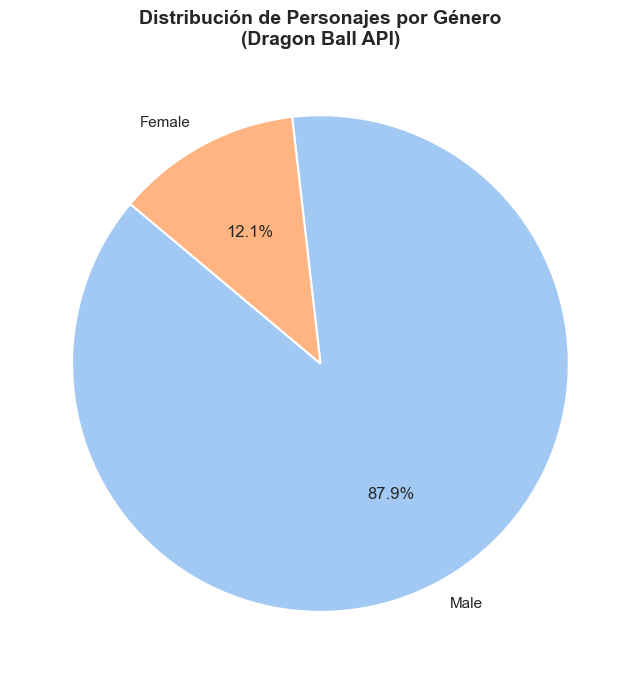

Gráfico guardado: grafico1_torta_genero.png


In [11]:
fig, ax = plt.subplots(figsize=(7, 7))

gender_counts.plot(
    kind='pie',
    ax=ax,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('pastel'),
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

ax.set_title('Distribución de Personajes por Género\n(Dragon Ball API)', fontsize=14, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('grafico1_torta_genero.png', dpi=150)
plt.show()
print('Gráfico guardado: grafico1_torta_genero.png')

### Gráfico 2 (Libre): Barras — Top 8 Razas más Frecuentes

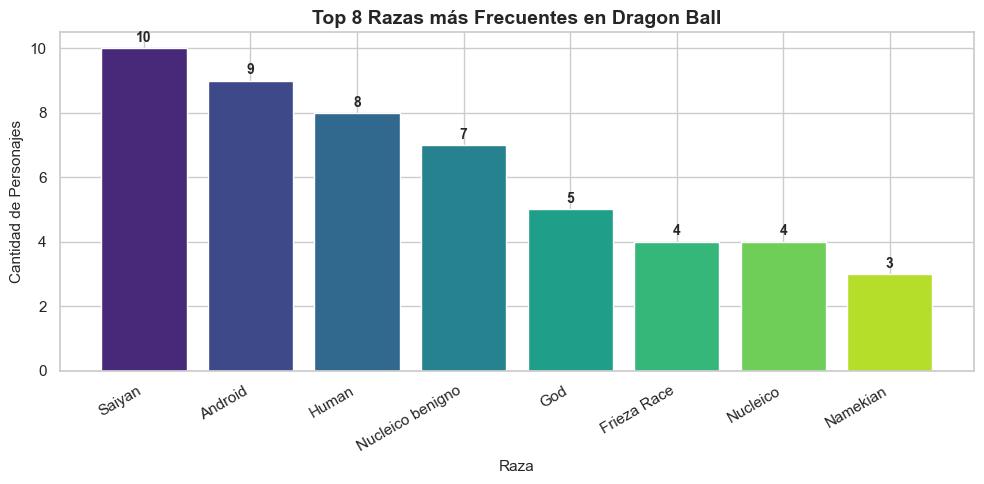

Gráfico guardado: grafico2_barras_razas.png


In [12]:
top_razas = df['race'].value_counts().head(8)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(top_razas.index, top_razas.values,
              color=sns.color_palette('viridis', len(top_razas)),
              edgecolor='white')

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.1,
            str(int(bar.get_height())),
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Top 8 Razas más Frecuentes en Dragon Ball', fontsize=14, fontweight='bold')
ax.set_xlabel('Raza', fontsize=11)
ax.set_ylabel('Cantidad de Personajes', fontsize=11)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('grafico2_barras_razas.png', dpi=150)
plt.show()
print('Gráfico guardado: grafico2_barras_razas.png')

### Gráfico 3 (Libre): Barras Horizontales — Top 6 Afiliaciones

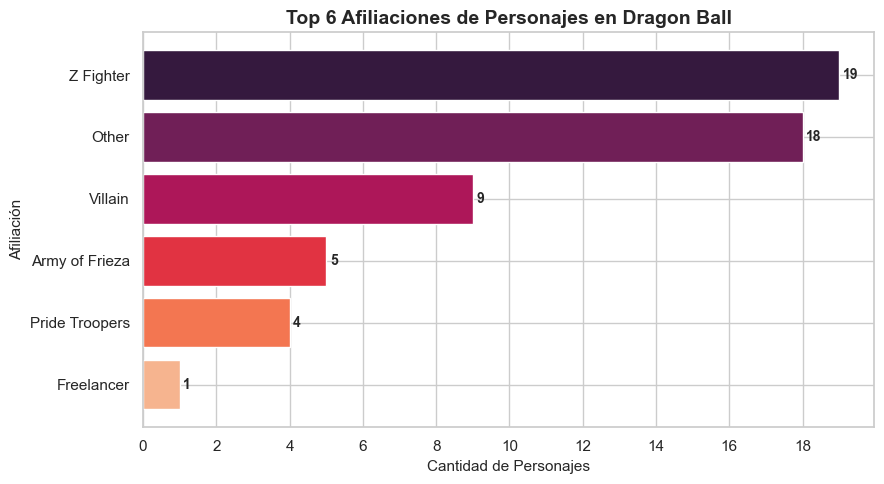

Gráfico guardado: grafico3_barras_afiliacion.png


In [13]:
top_afil = df['affiliation'].value_counts().head(6)

fig, ax = plt.subplots(figsize=(9, 5))
colors = sns.color_palette('rocket', len(top_afil))
bars = ax.barh(top_afil.index[::-1], top_afil.values[::-1], color=colors[::-1], edgecolor='white')

for bar in bars:
    ax.text(bar.get_width() + 0.1,
            bar.get_y() + bar.get_height() / 2,
            str(int(bar.get_width())),
            va='center', fontsize=10, fontweight='bold')

ax.set_title('Top 6 Afiliaciones de Personajes en Dragon Ball', fontsize=14, fontweight='bold')
ax.set_xlabel('Cantidad de Personajes', fontsize=11)
ax.set_ylabel('Afiliación', fontsize=11)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig('grafico3_barras_afiliacion.png', dpi=150)
plt.show()
print('Gráfico guardado: grafico3_barras_afiliacion.png')

## Insights — Resumen de Hallazgos

A partir del análisis exploratorio de los **58 personajes** de Dragon Ball se encontraron los siguientes hallazgos:

1. **Distribución por género:** La gran mayoría de personajes son masculinos, lo que refleja la composición histórica del universo Dragon Ball, donde los personajes femeninos relevantes son minoría.
2. **Raza dominante:** Los Saiyans y los Humans son las razas más representadas, consistente con el rol central que tienen en la narrativa de la serie.
3. **Afiliación principal:** Los Z Fighters concentran la mayor cantidad de personajes, seguidos de villanos y personajes neutrales.
4. **Personaje más poderoso:** El personaje con el Ki máximo más alto corresponde a una de las formas avanzadas de Goku o Vegeta, evidenciando el crecimiento exponencial del poder a lo largo de las sagas.
5. **Presencia Saiyan:** Aproximadamente el 17% de los personajes son Saiyans, lo que confirma que esta raza, a pesar de ser casi exterminada, tiene una influencia desproporcionada en el universo Dragon Ball.

In [14]:
# Cerrar conexión
client.close()
print('Conexión a MongoDB cerrada. Análisis completado.')

Conexión a MongoDB cerrada. Análisis completado.
